# Performance Report

This notebook summarizes model metrics for Objective 2 (leak detection) and Objective 3 (fault localisation).

- Load `models/leak_detection_metrics.json`
- Load `models/localization_metrics.json`
- Display classification reports
- Plot confusion matrices and model performance summaries
- Compare the old two-stage architecture to the new single-stage Random Forest pipeline

## Architecture Comparison

The original design used a two-stage pipeline:

- Stage 1: Isolation Forest anomaly detection on normal-only data
- Stage 2: Random Forest fault classification on flagged anomalies

That pipeline failed in practice because Stage 1 did not reliably detect faults, causing many leak/burst/blockage samples to be passed through as normal.

The current implementation uses a single-stage supervised classifier:

- `RandomForestClassifier` trained on all 4 classes
- Outputs `0=Normal`, `1=Leak`, `2=Burst`, `3=Blockage`
- Localization is still triggered only when a fault label is predicted

In [2]:
!pip install seaborn

In [ ]:
import json
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix

ROOT_DIR = Path("..")
MODELS_DIR = ROOT_DIR / "models"

leak_metrics_path = MODELS_DIR / "leak_detection_metrics.json"
localization_metrics_path = MODELS_DIR / "localization_metrics.json"

with open(leak_metrics_path, "r", encoding="utf-8") as handle:
    leak_metrics = json.load(handle)

with open(localization_metrics_path, "r", encoding="utf-8") as handle:
    localization_metrics = json.load(handle)

pd.options.display.max_columns = 25
pd.options.display.width = 120

leak_metrics.keys(), localization_metrics.keys()

## Quality Assessment

This cell checks whether the current saved models meet our target performance thresholds.

In [ ]:
leak_acc = leak_metrics.get("test", {}).get("classification_report", {}).get("accuracy", 0.0)
loc_acc = localization_metrics.get("test", {}).get("classification_report", {}).get("accuracy", 0.0)

print(f"Leak detection test accuracy: {leak_acc:.4f}")
print(f"Localization test accuracy: {loc_acc:.4f}\n")

if leak_acc >= 0.92:
    print("✓ Detection accuracy meets the target threshold.")
else:
    print("✗ Detection accuracy is below the target threshold. Retraining or feature engineering is recommended.")

if loc_acc >= 0.85:
    print("✓ Localization accuracy meets the target threshold.")
else:
    print("✗ Localization accuracy is below the target threshold. Retraining or localization feature review is recommended.")

# Show the 4-class detection baseline targets
print("\nTarget summary:")
print(" - Detection target: 0.92 overall accuracy")
print(" - Localization target: 0.85 overall accuracy")

In [ ]:
# Show the saved stage-2 detection metrics
leak_report = leak_metrics.get("test", {}).get("classification_report", {})
leak_confusion = leak_metrics.get("test", {}).get("confusion_matrix", [])

leak_report_df = pd.DataFrame(leak_report).T
print("Leak Detection Test Classification Report")
print(leak_report_df.to_string())
print("\nLeak Detection Test Confusion Matrix")
print(pd.DataFrame(
    leak_confusion,
    columns=["pred_normal", "pred_leak", "pred_burst", "pred_blockage"],
    index=["true_normal", "true_leak", "true_burst", "true_blockage"],
).to_string())

# Show localization metrics if available
localization_report = localization_metrics.get("test", {}).get("classification_report", {})
localization_confusion = localization_metrics.get("test", {}).get("confusion_matrix", [])

localization_report_df = pd.DataFrame(localization_report).T
print("\nLocalization Test Classification Report")
if localization_report_df.shape[0] > 20:
    print(localization_report_df.loc[["accuracy", "macro avg", "weighted avg"]].to_string())
    print("\nLocalization class-level report (first 15 classes):")
    print(localization_report_df.iloc[:15].to_string())
    if localization_report_df.shape[0] > 15:
        print(f"\n... plus {localization_report_df.shape[0] - 15} additional classes.")
else:
    print(localization_report_df.to_string())

print("\nLocalization Test Confusion Matrix")
if localization_confusion:
    loc_conf_df = pd.DataFrame(localization_confusion)
    print("Localization confusion matrix shape:", loc_conf_df.shape)
    print(loc_conf_df.iloc[:10, :10].to_string())
    if loc_conf_df.shape[0] > 10 or loc_conf_df.shape[1] > 10:
        print("\nShowing first 10 rows and 10 columns of the localization confusion matrix.")
else:
    print("No confusion matrix found in localization metrics.")

Leak Detection Test Classification Report
              precision    recall  f1-score     support
0              0.279503  1.000000  0.436893  135.000000
1              1.000000  0.148148  0.258065  135.000000
2              1.000000  0.111111  0.200000  135.000000
3              1.000000  0.162963  0.280255  135.000000
accuracy       0.355556  0.355556  0.355556    0.355556
macro avg      0.819876  0.355556  0.293803  540.000000
weighted avg   0.819876  0.355556  0.293803  540.000000

Leak Detection Test Confusion Matrix
               pred_normal  pred_leak  pred_burst  pred_blockage
true_normal            135          0           0              0
true_leak              115         20           0              0
true_burst             120          0          15              0
true_blockage          113          0           0             22

Localization Test Classification Report
              precision    recall  f1-score     support
0              0.741758  1.000000  0.851735  135.0

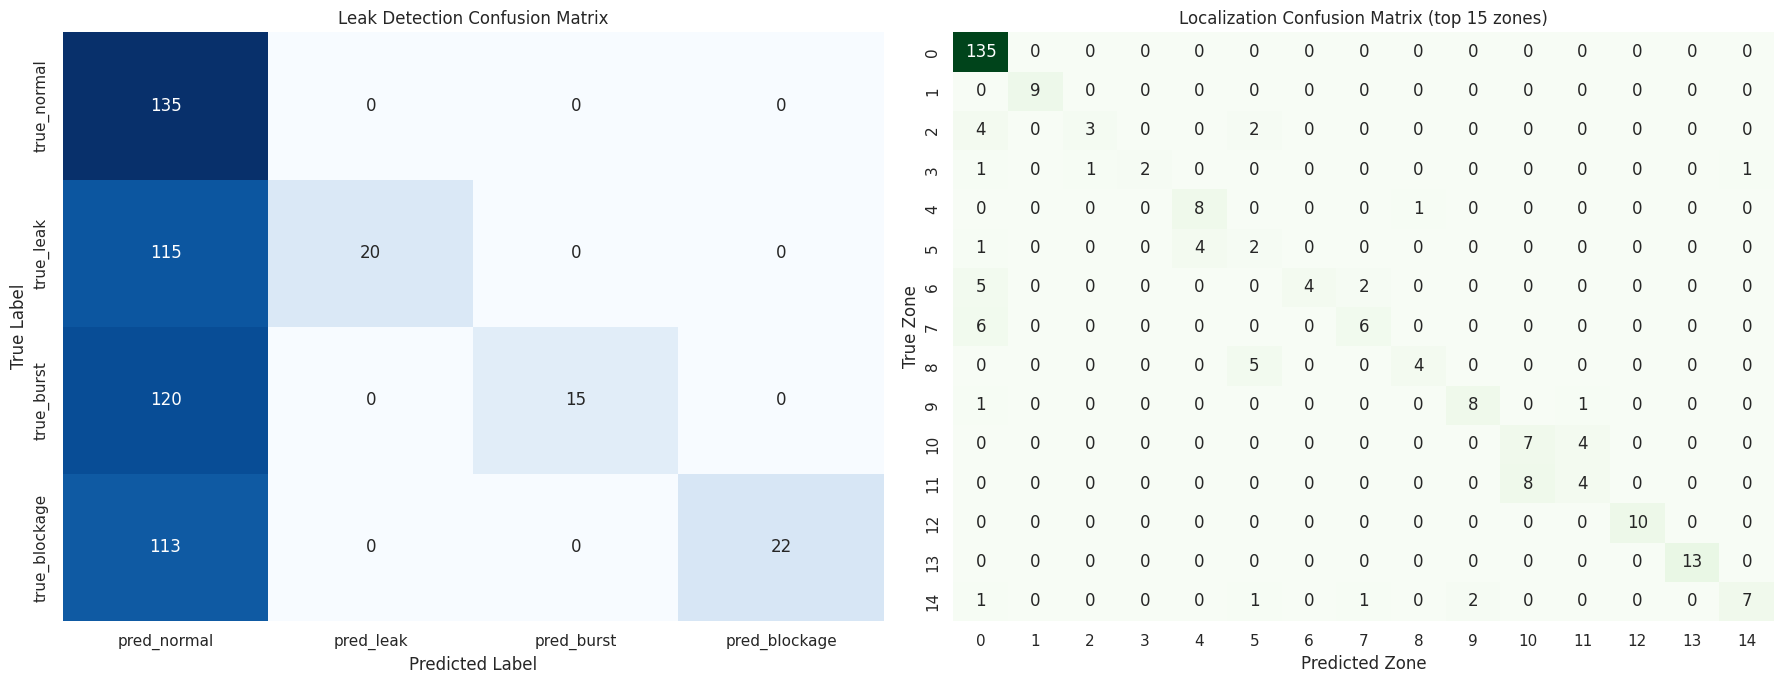

In [7]:
# Plot confusion matrices
sns.set(style="whitegrid", font_scale=1.0)

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

if leak_confusion:
    ax = axes[0]
    sns.heatmap(
        pd.DataFrame(
            leak_confusion,
            columns=["pred_normal", "pred_leak", "pred_burst", "pred_blockage"],
            index=["true_normal", "true_leak", "true_burst", "true_blockage"],
        ),
        annot=True,
        fmt="d",
        cmap="Blues",
        ax=ax,
        cbar=False,
    )
    ax.set_title("Leak Detection Confusion Matrix")
    ax.set_xlabel("Predicted Label")
    ax.set_ylabel("True Label")
else:
    axes[0].text(0.5, 0.5, "No leak confusion matrix available", ha="center", va="center")
    axes[0].axis("off")

if localization_confusion:
    ax = axes[1]
    loc_conf_df = pd.DataFrame(localization_confusion)
    loc_conf_plot = loc_conf_df.iloc[:15, :15]
    sns.heatmap(
        loc_conf_plot,
        annot=True,
        fmt="d",
        cmap="Greens",
        ax=ax,
        cbar=False,
    )
    ax.set_title("Localization Confusion Matrix (top 15 zones)")
    ax.set_xlabel("Predicted Zone")
    ax.set_ylabel("True Zone")
else:
    axes[1].text(0.5, 0.5, "No localization confusion matrix available", ha="center", va="center")
    axes[1].axis("off")

plt.tight_layout()
plt.show()